# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [13]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

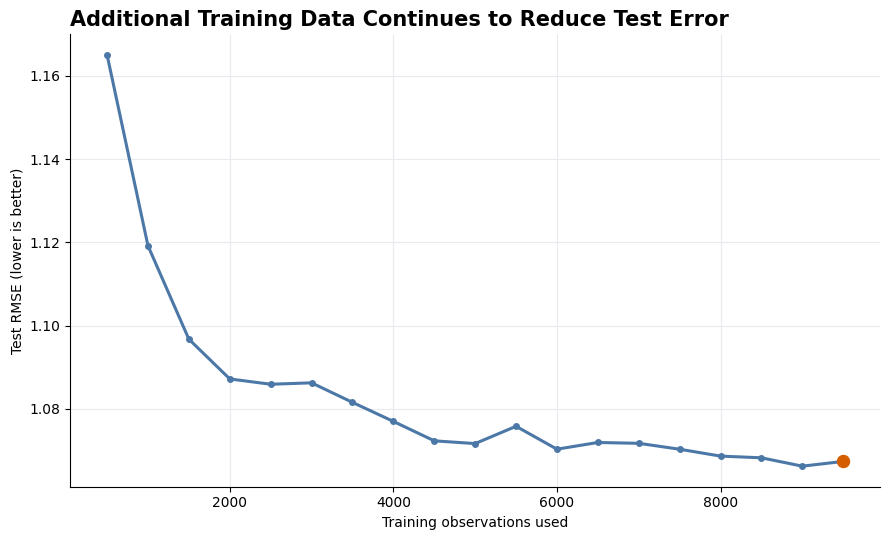

In [15]:
training_sizes = list(range(round(num_points / 20), num_points, round(num_points / 20)))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(training_sizes, rmse_lst, color="#4C78A8", linewidth=2.2, marker="o", markersize=4)
ax.scatter(training_sizes[-1], rmse_lst[-1], color="#D55E00", s=75, zorder=3)
ax.set_title("Additional Training Data Continues to Reduce Test Error",
             loc="left", fontsize=15, weight="bold")
ax.set_xlabel("Training observations used")
ax.set_ylabel("Test RMSE (lower is better)")
ax.grid(color="#E8EAED")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

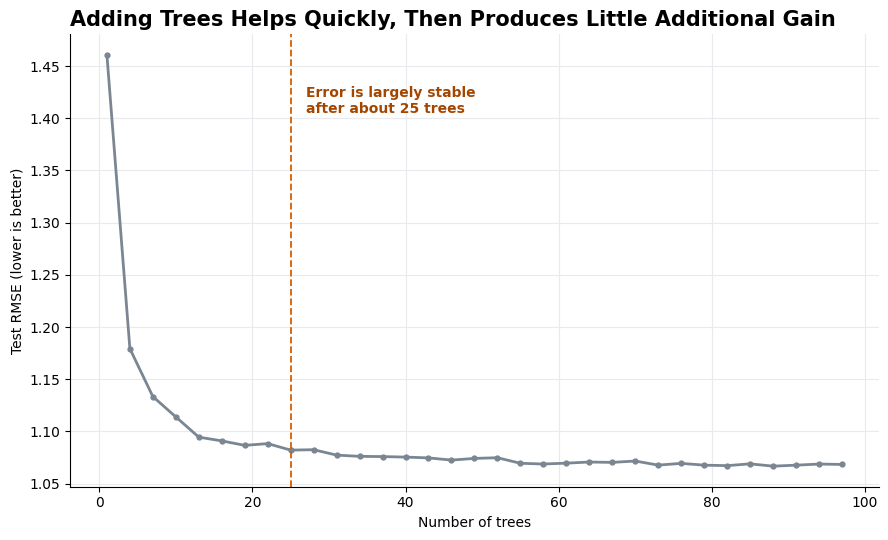

In [ ]:
tree_counts = list(range(1, 100, 3))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(tree_counts, num_trees_lst, color="#7A8793", linewidth=2, marker="o", markersize=3.5)
ax.axvline(25, color="#D55E00", linestyle="--", linewidth=1.3)
ax.text(27, max(num_trees_lst) - .03, "Error is largely stable\nafter about 25 trees",
        color="#A34700", weight="bold", va="top")
ax.set_title("Adding Trees Helps Quickly, Then Produces Little Additional Gain",
             loc="left", fontsize=15, weight="bold")
ax.set_xlabel("Number of trees")
ax.set_ylabel("Test RMSE (lower is better)")
ax.grid(color="#E8EAED")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Weekly graph response

I would cut the **number-of-estimators** plot. It shows a useful implementation detail—error stabilizes once the forest contains enough trees—but the training-data learning curve is more important for a decision-maker. It reveals whether collecting or retaining more observations is likely to improve performance and shows clear diminishing returns. The training-data plot should remain, with **amount of training data used** on the x-axis. Its current tick labels should be converted from an index ending at 20 to actual observation counts, and `Loss function` should be renamed `Test RMSE`. If the estimator plot were retained for a technical appendix, its x-axis should display the actual values 1, 4, 7, ... rather than list positions.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

## Random Forest models for the two selected loan datasets

This section uses only `DATA/Loan_Default.csv` and the accepted Lending Club file. Home Credit is intentionally excluded because it was not selected for continued analysis. Both targets are binary, so `RandomForestClassifier` is used. Models are evaluated on untouched stratified test sets; `RandomizedSearchCV` tunes hyperparameters using three-fold stratified cross-validation and ROC AUC.

In [18]:
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix
from scipy.stats import randint

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
parameter_distributions = {
    "model__n_estimators": randint(120, 321),
    "model__max_depth": [8, 12, 18, None],
    "model__min_samples_leaf": randint(2, 15),
    "model__max_features": ["sqrt", 0.7, 1.0]
}

def tune_and_evaluate(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=.25, stratify=y, random_state=RANDOM_STATE
    )
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ])
    search = RandomizedSearchCV(
        pipeline, parameter_distributions, n_iter=8, scoring="roc_auc", cv=cv,
        random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True
    )
    search.fit(X_train, y_train)
    probabilities = search.best_estimator_.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= .5).astype(int)
    metrics_row = {
        "dataset": dataset_name,
        "rows": len(X),
        "adverse_rate": y.mean(),
        "CV_ROC_AUC": search.best_score_,
        "test_ROC_AUC": roc_auc_score(y_test, probabilities),
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_precision": precision_score(y_test, predictions, zero_division=0),
        "test_recall": recall_score(y_test, predictions),
    }
    importances = pd.Series(
        search.best_estimator_.named_steps["model"].feature_importances_,
        index=X.columns, name=dataset_name
    ).sort_values(ascending=False)
    evaluation = pd.DataFrame({
        "actual": np.asarray(y_test),
        "predicted_probability": probabilities
    })
    return (
        metrics_row, importances, search.best_params_,
        confusion_matrix(y_test, predictions), evaluation
    )

# Mortgage Loan Default.
mortgage_features = ["loan_amount", "property_value", "income", "LTV", "Credit_Score", "dtir1"]
mortgage = pd.read_csv("DATA/Loan_Default.csv", usecols=mortgage_features + ["Status"])
# Complete-case restriction prevents missing underwriting fields from acting as
# near-perfect proxies for Status. rate_of_interest is deliberately excluded because
# its missingness almost perfectly reveals the outcome in this file.
mortgage = mortgage.replace([np.inf, -np.inf], np.nan).dropna(
    subset=mortgage_features + ["Status"]
)
mortgage_X = mortgage[mortgage_features]
mortgage_y = mortgage["Status"].astype(int)

# Accepted Lending Club: evenly spaced sample from the full 2007-2018 file.
accepted_path = Path("DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv")
lending_features = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti",
                    "fico_range_low", "open_acc", "revol_util", "total_acc"]
accepted_total_rows = sum(1 for _ in open(accepted_path, encoding="utf-8")) - 1
accepted_every = max(accepted_total_rows // 60000, 1)
accepted = pd.read_csv(
    accepted_path, usecols=lending_features + ["loan_status"],
    skiprows=lambda row: row > 0 and row % accepted_every != 0, low_memory=False
)
bad_statuses = {"Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
                "Does not meet the credit policy. Status:Charged Off"}
accepted["bad_loan"] = accepted["loan_status"].isin(bad_statuses).astype(int)
lending_X = accepted[lending_features].replace([np.inf, -np.inf], np.nan)
lending_y = accepted["bad_loan"]

print(f"Mortgage rows: {len(mortgage):,}; accepted Lending Club sampled rows: {len(accepted):,}")

Mortgage rows: 124,437; accepted Lending Club sampled rows: 61,100


### Tune and evaluate both models

In [19]:
mortgage_result = tune_and_evaluate(mortgage_X, mortgage_y, "Mortgage Loan Default")
lending_result = tune_and_evaluate(lending_X, lending_y, "Accepted Lending Club")

model_metrics = pd.DataFrame([mortgage_result[0], lending_result[0]])
display(model_metrics.style.format({
    "adverse_rate": "{:.1%}", "CV_ROC_AUC": "{:.3f}", "test_ROC_AUC": "{:.3f}",
    "test_accuracy": "{:.3f}", "test_precision": "{:.3f}", "test_recall": "{:.3f}"
}))
print("Mortgage best parameters:", mortgage_result[2])
print("Lending Club best parameters:", lending_result[2])

,dataset,rows,adverse_rate,CV_ROC_AUC,test_ROC_AUC,test_accuracy,test_precision,test_recall
0,Mortgage Loan Default,124437,16.3%,0.730,0.723,0.760,0.345,0.525
1,Accepted Lending Club,61100,13.0%,0.695,0.698,0.648,0.215,0.643


Mortgage best parameters: {'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 13, 'model__n_estimators': 208}
Lending Club best parameters: {'model__max_depth': 8, 'model__max_features': 1.0, 'model__min_samples_leaf': 12, 'model__n_estimators': 289}


### Feature importance and conclusions

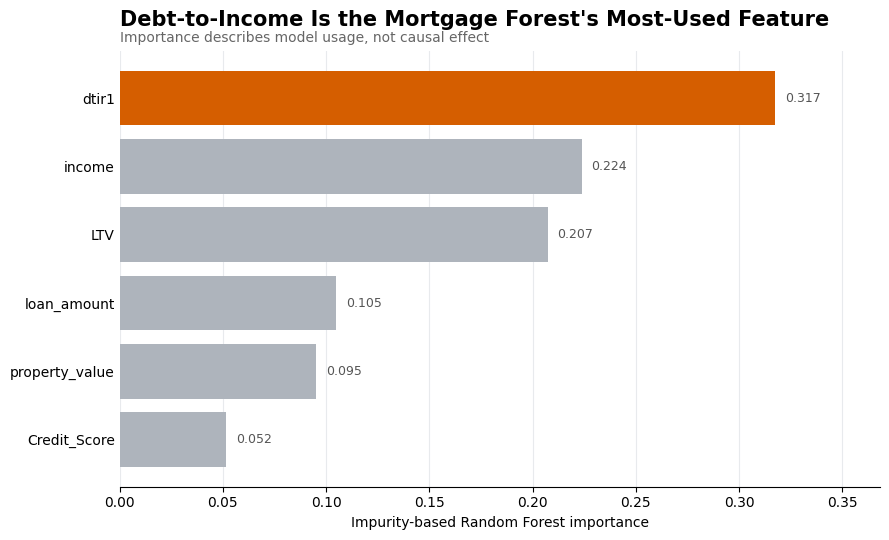

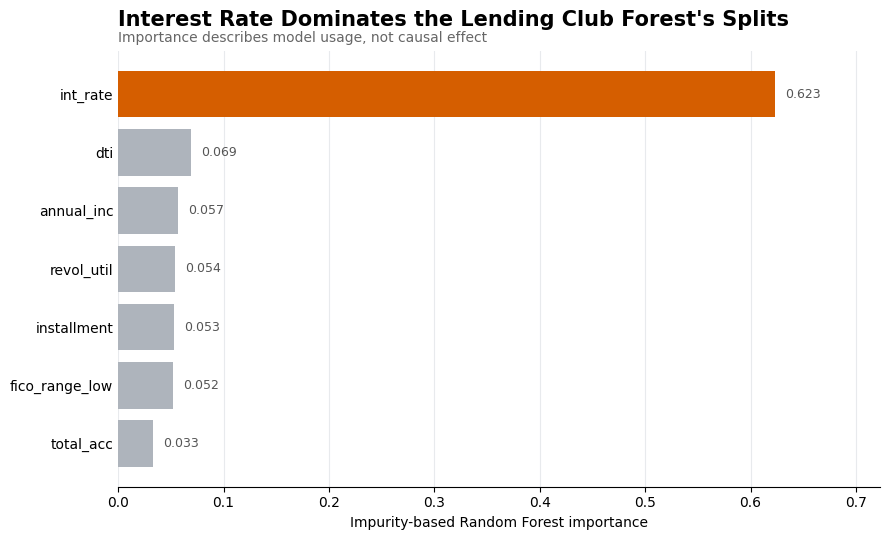

Mortgage confusion matrix:
 [[20974  5056]
 [ 2413  2667]]
Lending Club confusion matrix:
 [[8621 4662]
 [ 712 1280]]


In [20]:
def plot_feature_importance(importances, title, subtitle):
    ordered = importances.sort_values().tail(7)
    colors = ["#AEB4BC"] * (len(ordered) - 1) + ["#D55E00"]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars = ax.barh(ordered.index, ordered.values, color=colors)
    for bar, value in zip(bars, ordered.values):
        ax.text(value + ordered.max() * .015, bar.get_y() + bar.get_height()/2,
                f"{value:.3f}", va="center", fontsize=9, color="#555555")
    ax.set_xlim(0, ordered.max() * 1.16)
    ax.set_title(title, loc="left", fontsize=15, weight="bold", pad=18)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color="#666666", fontsize=10)
    ax.set_xlabel("Impurity-based Random Forest importance")
    ax.grid(axis="x", color="#E8EAED")
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    plt.tight_layout()
    plt.show()

plot_feature_importance(
    mortgage_result[1],
    "Debt-to-Income Is the Mortgage Forest's Most-Used Feature",
    "Importance describes model usage, not causal effect"
)
plot_feature_importance(
    lending_result[1],
    "Interest Rate Dominates the Lending Club Forest's Splits",
    "Importance describes model usage, not causal effect"
)

print("Mortgage confusion matrix:\n", mortgage_result[3])
print("Lending Club confusion matrix:\n", lending_result[3])

**Conclusions.** The models should be judged primarily by held-out ROC AUC because the adverse classes are imbalanced and the operational threshold has not been specified. Cross-validation and test scores should be reasonably close; a large gap would indicate instability or overfitting. Feature importance identifies variables the forest used for splitting, not causal effects. Mortgage and Lending Club importances should not be compared numerically as if the schemas were identical. Missing numeric values are median-imputed inside each cross-validation fold, preventing test-fold information leakage. The accepted-loan sample is evenly spaced across the source file for reproducibility, but a time-based validation would be a stronger next step because lending standards and borrower populations can change.\n\n**Leakage check.** Mortgage records with missing property value, LTV, or interest rate are overwhelmingly labeled `Status = 1`. To prevent missingness from acting as an outcome proxy, the mortgage forest excludes `rate_of_interest` and uses complete cases for the six retained pre-outcome features. Its metrics therefore describe that complete-case population, not every row in the source file.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

## Story 1 - Mortgage Loan Default

Chapter 7 asks for a coherent beginning, middle, and end. This first standalone story makes mortgage decision-makers the audience: it establishes the default problem, presents held-out model evidence, and ends with a bounded action.

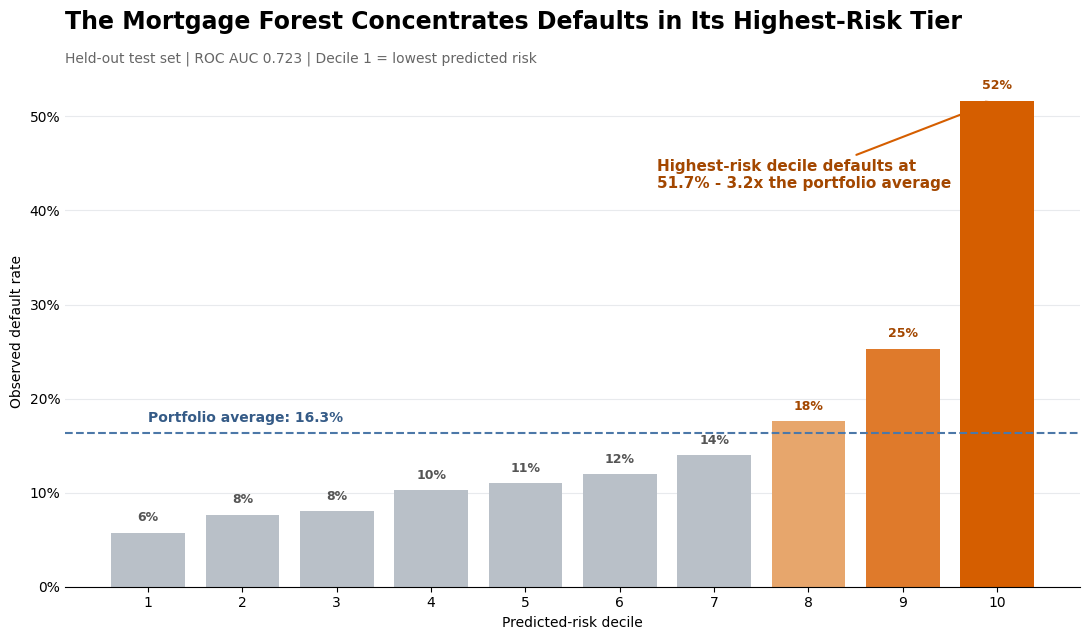

In [21]:
# Mortgage story: translate model scores into observed risk tiers.
mortgage_row = model_metrics.loc[
    model_metrics["dataset"].eq("Mortgage Loan Default")
].iloc[0]
mortgage_deciles = mortgage_result[4].copy()
mortgage_deciles["risk_decile"] = pd.qcut(
    mortgage_deciles["predicted_probability"].rank(method="first"), 10, labels=range(1, 11)
)
mortgage_lift = (
    mortgage_deciles.groupby("risk_decile", observed=True)
    .agg(observed_default_rate=("actual", "mean"),
         average_score=("predicted_probability", "mean"),
         loans=("actual", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = ["#B9C0C8"] * 7 + ["#E7A66C", "#DF7A2B", "#D55E00"]
bars = ax.bar(mortgage_lift["risk_decile"].astype(int),
              mortgage_lift["observed_default_rate"], color=colors, width=.78)
for bar, rate in zip(bars, mortgage_lift["observed_default_rate"]):
    ax.text(bar.get_x()+bar.get_width()/2, rate+.012, f"{rate:.0%}",
            ha="center", fontsize=9, weight="bold",
            color="#A34700" if bar.get_x()+bar.get_width()/2 >= 8 else "#555555")
ax.axhline(mortgage_row["adverse_rate"], color="#4C78A8", linestyle="--", linewidth=1.5)
ax.text(1.0, mortgage_row["adverse_rate"]+.012,
        f'Portfolio average: {mortgage_row["adverse_rate"]:.1%}',
        color="#355B87", fontsize=10, weight="bold")
top_rate = mortgage_lift.iloc[-1]["observed_default_rate"]
ax.annotate(
    f"Highest-risk decile defaults at\n{top_rate:.1%} - "
    f"{top_rate/mortgage_row['adverse_rate']:.1f}x the portfolio average",
    xy=(10, top_rate), xytext=(6.4, max(mortgage_lift["observed_default_rate"])*.82),
    arrowprops={"arrowstyle": "->", "color": "#D55E00", "lw": 1.5},
    color="#A34700", weight="bold", fontsize=11
)
ax.set_title("The Mortgage Forest Concentrates Defaults in Its Highest-Risk Tier",
             loc="left", fontsize=17, weight="bold", pad=34)
ax.text(0, 1.02,
        f'Held-out test set | ROC AUC {mortgage_row["test_ROC_AUC"]:.3f} | '
        "Decile 1 = lowest predicted risk",
        transform=ax.transAxes, color="#666666", fontsize=10, va="bottom")
ax.set_xlabel("Predicted-risk decile")
ax.set_ylabel("Observed default rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_xticks(range(1, 11))
ax.grid(axis="y", color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

**Mortgage story takeaway.** The Chapter 7 story now unfolds in one reading path: the portfolio average establishes the problem, ordered risk deciles show how the model separates outcomes, and the annotation identifies the operationally important high-risk group. The evidence supports prioritized human review, not automatic denial.

## Story 2 - Accepted Lending Club Loans

This second standalone Chapter 7 story follows the same narrative discipline but uses Lending Club's own outcome, model, features, and recommendation.

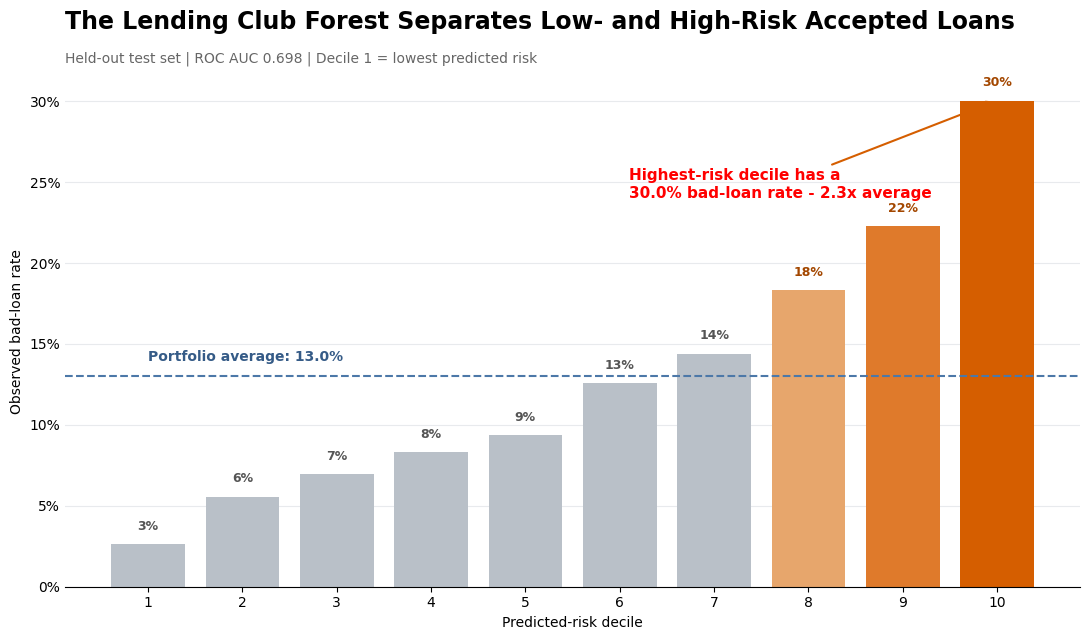

In [27]:
# Lending Club story: translate model scores into observed risk tiers.
lending_row = model_metrics.loc[
    model_metrics["dataset"].eq("Accepted Lending Club")
].iloc[0]
lending_deciles = lending_result[4].copy()
lending_deciles["risk_decile"] = pd.qcut(
    lending_deciles["predicted_probability"].rank(method="first"), 10, labels=range(1, 11)
)
lending_lift = (
    lending_deciles.groupby("risk_decile", observed=True)
    .agg(observed_bad_loan_rate=("actual", "mean"),
         average_score=("predicted_probability", "mean"),
         loans=("actual", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = ["#B9C0C8"] * 7 + ["#E7A66C", "#DF7A2B", "#D55E00"]
bars = ax.bar(lending_lift["risk_decile"].astype(int),
              lending_lift["observed_bad_loan_rate"], color=colors, width=.78)
for bar, rate in zip(bars, lending_lift["observed_bad_loan_rate"]):
    ax.text(bar.get_x()+bar.get_width()/2, rate+.009, f"{rate:.0%}",
            ha="center", fontsize=9, weight="bold",
            color="#A34700" if bar.get_x()+bar.get_width()/2 >= 8 else "#555555")
ax.axhline(lending_row["adverse_rate"], color="#4C78A8", linestyle="--", linewidth=1.5)
ax.text(1.0, lending_row["adverse_rate"]+.009,
        f'Portfolio average: {lending_row["adverse_rate"]:.1%}',
        color="#355B87", fontsize=10, weight="bold")
top_rate = lending_lift.iloc[-1]["observed_bad_loan_rate"]
ax.annotate(
    f"Highest-risk decile has a\n{top_rate:.1%} bad-loan rate - "
    f"{top_rate/lending_row['adverse_rate']:.1f}x average",
    xy=(10, top_rate), xytext=(6.1, max(lending_lift["observed_bad_loan_rate"])*.80),
    arrowprops={"arrowstyle": "->", "color": "#D55E00", "lw": 1.5},
    color="red", weight="bold", fontsize=11
)
ax.set_title("The Lending Club Forest Separates Low- and High-Risk Accepted Loans",
             loc="left", fontsize=17, weight="bold", pad=34)
ax.text(0, 1.02,
        f'Held-out test set | ROC AUC {lending_row["test_ROC_AUC"]:.3f} | '
        "Decile 1 = lowest predicted risk",
        transform=ax.transAxes, color="#666666", fontsize=10, va="bottom")
ax.set_xlabel("Predicted-risk decile")
ax.set_ylabel("Observed bad-loan rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_xticks(range(1, 11))
ax.grid(axis="y", color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

**Lending Club story takeaway.** The ordered held-out deciles make the narrative concrete: predicted risk rises from left to right, observed bad-loan outcomes provide the evidence, and the highlighted final tiers identify where monitoring should focus. Time-based validation remains necessary before operational use.